<a href="https://colab.research.google.com/github/rc2308/churn-ensemble-engine/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clone your GitHub repo (gets the latest src/ files)
!git clone https://github.com/rc2308/churn-ensemble-engine.git
%cd churn-ensemble-engine

# Install dependencies
!pip install -q -r requirements.txt


In [2]:
# Clone your GitHub repo (gets the latest src/ files)
!git clone https://github.com/rc2308/churn-ensemble-engine.git
%cd churn-ensemble-engine

# Install dependencies
!pip install -q -r requirements.txt


Cloning into 'churn-ensemble-engine'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 21 (delta 6), reused 18 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), done.
Resolving deltas: 100% (6/6), done.
/content/churn-ensemble-engine
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 87.7 MB/s eta 0:00:00


In [3]:
# Upload BankChurners.csv from your laptop
from google.colab import files
uploaded = files.upload()   # a "Choose Files" button appears -> select BankChurners.csv


Saving BankChurners.csv to BankChurners.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import YOUR functions from src/
from src.data_prep import load_data, clean_data, split_data

# Load the raw data
df_raw = load_data("BankChurners.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [5]:
# Clean using your function
df = clean_data(df_raw)
print("Shape after cleaning:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape after cleaning: (10127, 20)

Columns: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Churn']


,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


Churn rate: 16.1%


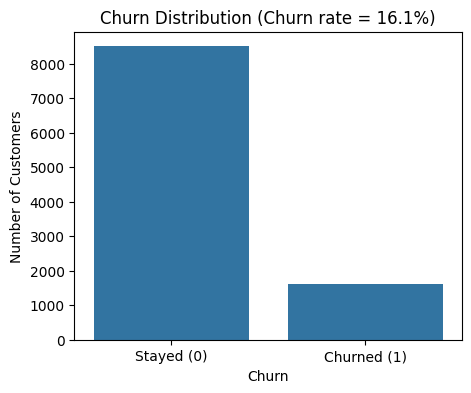

In [11]:
# How imbalanced is the data?
churn_rate = df["Churn"].mean()
print(f"Churn rate: {churn_rate:.1%}")

# Visualize
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title(f"Churn Distribution (Churn rate = {churn_rate:.1%})")
plt.xticks([0,1], ["Stayed (0)", "Churned (1)"])
plt.ylabel("Number of Customers")
plt.savefig("reports/figures/churn_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


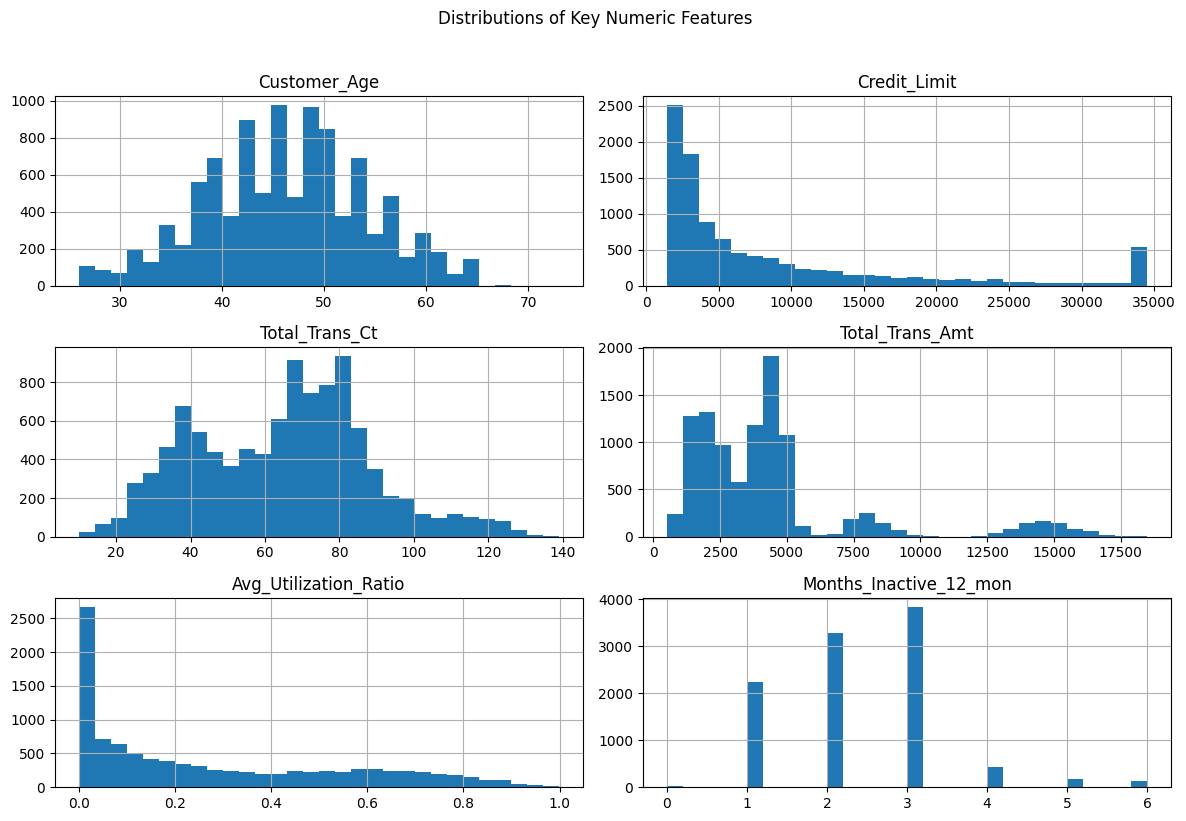

In [7]:
# Distributions of a few key numeric features
key_features = ["Customer_Age", "Credit_Limit", "Total_Trans_Ct",
                "Total_Trans_Amt", "Avg_Utilization_Ratio", "Months_Inactive_12_mon"]

df[key_features].hist(figsize=(12,8), bins=30)
plt.suptitle("Distributions of Key Numeric Features", y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/feature_distributions.png", bbox_inches="tight", dpi=150)
plt.show()


/tmp/ipykernel_1462/2123369227.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])
/tmp/ipykernel_1462/2123369227.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])
/tmp/ipykernel_1462/2123369227.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])
/tmp/ipykernel_1462/2123369227.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Churned"])
/tmp/ipykernel_1462/2123369227.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

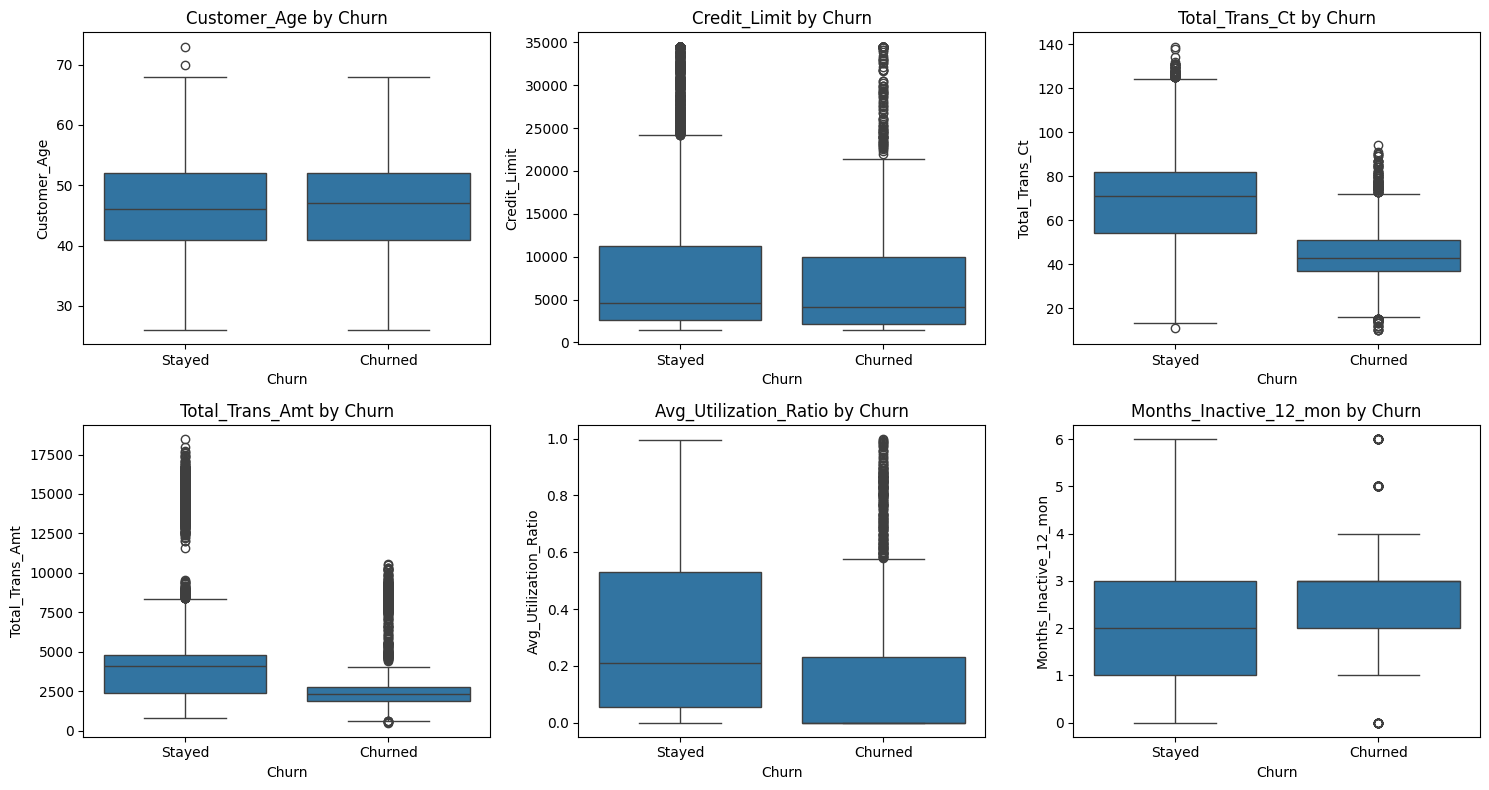

In [8]:
# Compare churned vs stayed across key behaviors
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, feat in zip(axes.flatten(), key_features):
    sns.boxplot(x="Churn", y=feat, data=df, ax=ax)
    ax.set_title(f"{feat} by Churn")
    ax.set_xticklabels(["Stayed", "Churned"])
plt.tight_layout()
plt.savefig("reports/figures/churn_vs_features.png", bbox_inches="tight", dpi=150)
plt.show()


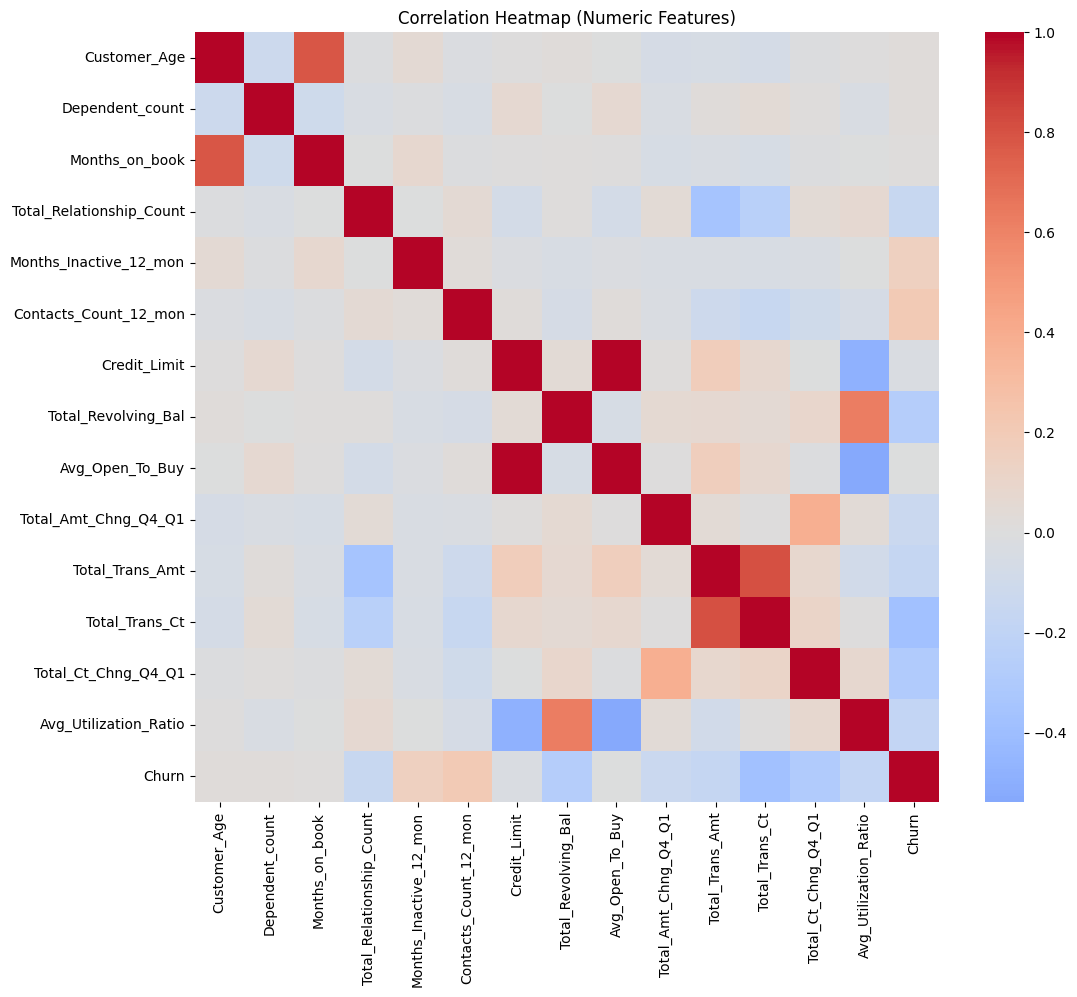

In [9]:
# Correlation among numeric features (incl. Churn)
plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.savefig("reports/figures/correlation_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()


## Key EDA Insights

1. **Class imbalance:** ~16.1% churn — we will use `scale_pos_weight` / stratified split
   to prevent the model from ignoring the minority (churned) class.

2. **Transaction behavior (strongest signal):** Churned customers have clearly fewer
   total transactions (`Total_Trans_Ct` median ~43 vs ~71 for stayed) and lower
   transaction amounts (`Total_Trans_Amt` median ~2,500 vs ~4,000). This is the most
   visually separated feature — low engagement strongly predicts churn.

3. **Inactivity:** Churned customers show slightly higher `Months_Inactive_12_mon`
   (median ~2.5 vs ~2). The upward shift, though modest, indicates disengagement
   precedes attrition.

4. **Utilization:** Churned customers have noticeably lower `Avg_Utilization_Ratio`
   (median near 0, with most below 0.25) compared to stayed customers (median ~0.20,
   spread up to ~0.55). Customers who stopped using their available credit are more
   likely to leave — a key behavioral churn signal.

5. **Credit limit & age:** `Credit_Limit` is only marginally lower for churned
   customers, and `Customer_Age` shows almost no difference between groups — so
   demographics are weak churn predictors compared to behavioral features.

6. **Correlations (heatmap):** `Churn` shows its strongest (negative) correlations with
   `Total_Trans_Ct`, `Total_Trans_Amt`, and `Total_Ct_Chng_Q4_Q1`, and a mild positive
   correlation with `Contacts_Count_12_mon` and `Months_Inactive_12_mon`. Notably,
   `Credit_Limit` and `Avg_Open_To_Buy` are almost perfectly correlated (redundant),
   and `Total_Trans_Amt`/`Total_Trans_Ct` are highly correlated with each other.

**Conclusion:** Behavioral and transactional features (transaction count/amount,
utilization, transaction-count change) are the dominant churn drivers, while
demographic features (age) are weak. This justifies engineering and prioritizing
behavioral/RFM-style features in the next stage.

